# **TRAFFIC DEMAND FORECASTING**
---

**Objective:** Predict normalised traffic `demand` (0–1) for geohash-timestamped road segments using an ensemble of LightGBM and CatBoost.

**Final Score:** R² ≈ 0.91604 (after post-processing bias correction)

## Table of Contents
1. [Data Overview & Loading](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Feature Engineering](#3)
4. [Target Transformation](#4)
5. [Leak-Free Target Encoding](#5)
6. [Categorical Encoding](#6)
7. [Correlation Analysis](#7)
8. [Feature Selection — Ablation Experiments](#8)
9. [Model Training — LightGBM + CatBoost Ensemble](#9)
10. [Hyperparameter Tuning (Optuna — archived)](#10)
11. [Ensemble & Inverse Transform](#11)
12. [Post-Processing Bias Correction](#12)
13. [Final Submission](#13)
14. [Results Summary](#14)

## **INSTALLATION AND IMPORTS**

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 6.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import lightgbm as lgb
from catboost import CatBoostRegressor
import warnings
import optuna
warnings.filterwarnings('ignore')


# **DATA LOADING**

In [ ]:
print("Loading data...")

url_test = 'https://raw.githubusercontent.com/kapilbagaria093/dataset-ml/refs/heads/main/test.csv'
url_train = 'https://raw.githubusercontent.com/kapilbagaria093/dataset-ml/refs/heads/main/train.csv'

train = pd.read_csv(url_train)
test  = pd.read_csv(url_test)

Loading data...


# **DATA VISUALISATION**

DATASET INFO
(77299, 11)

count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64


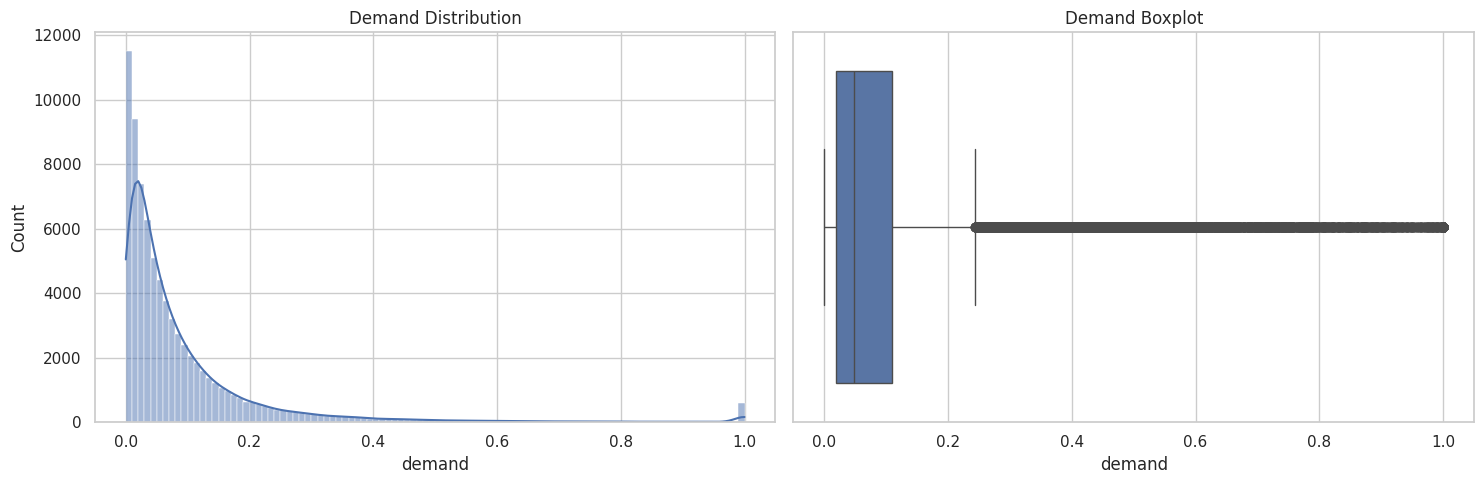

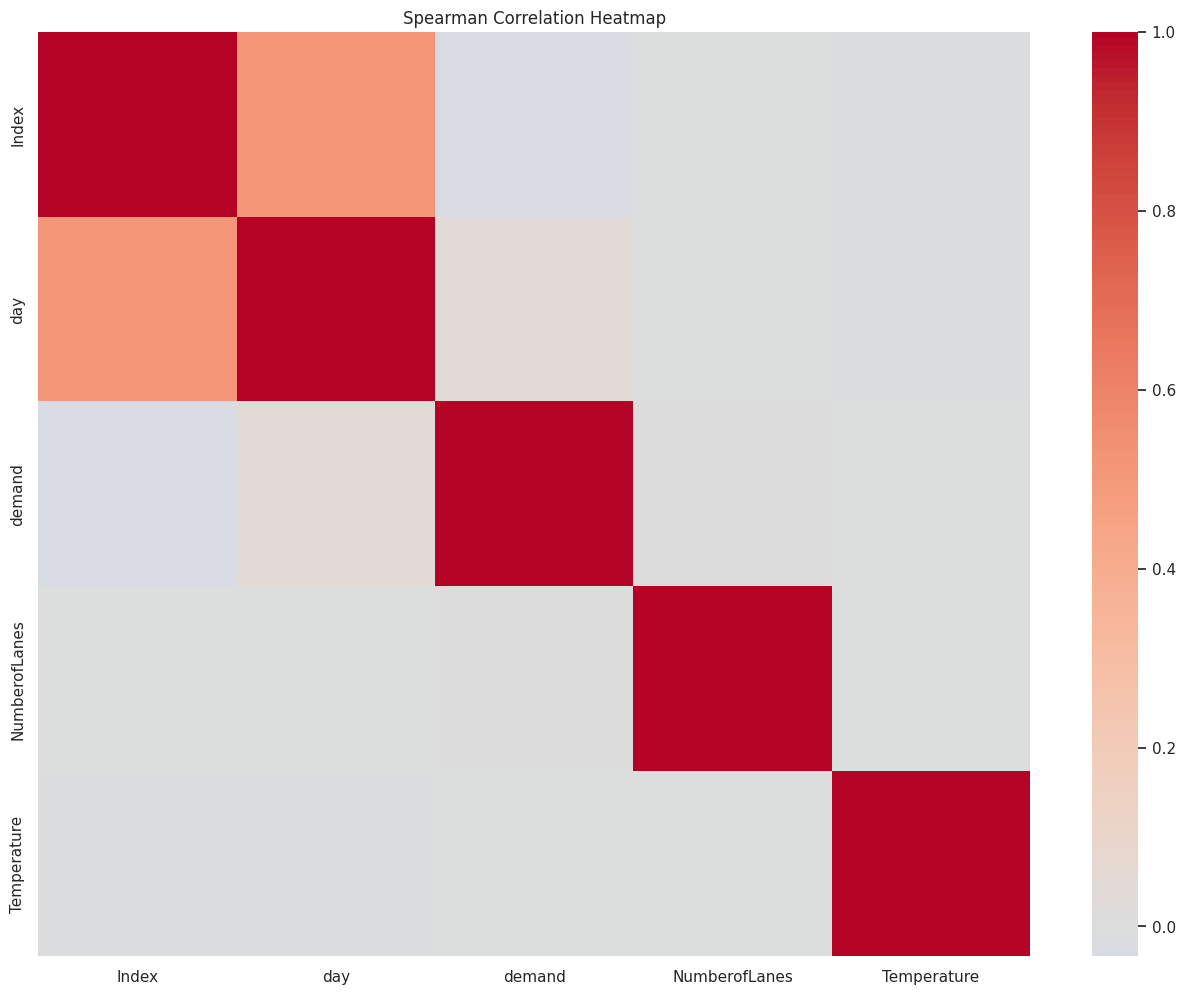

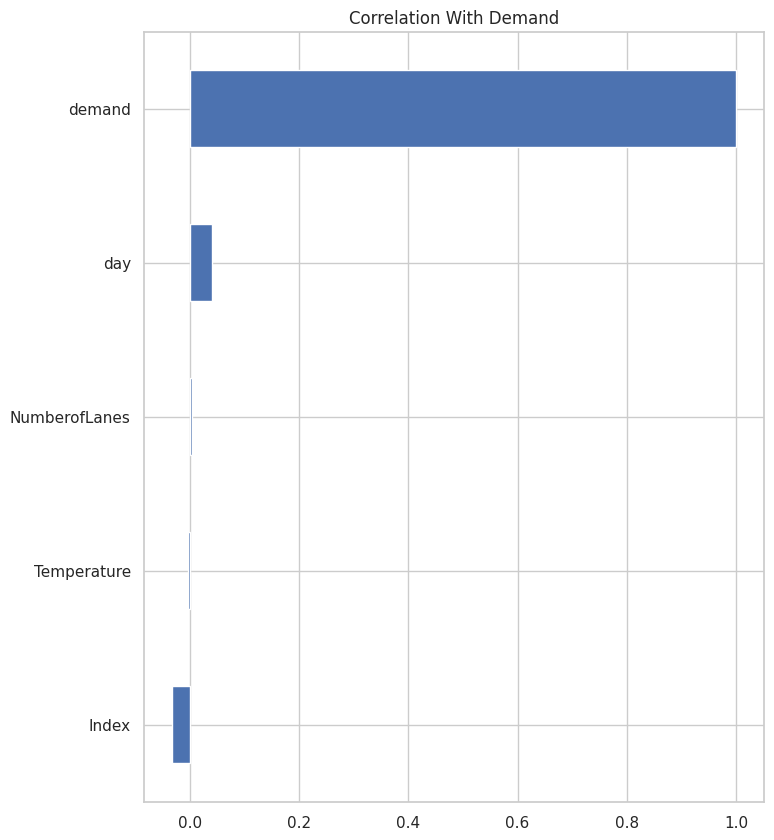

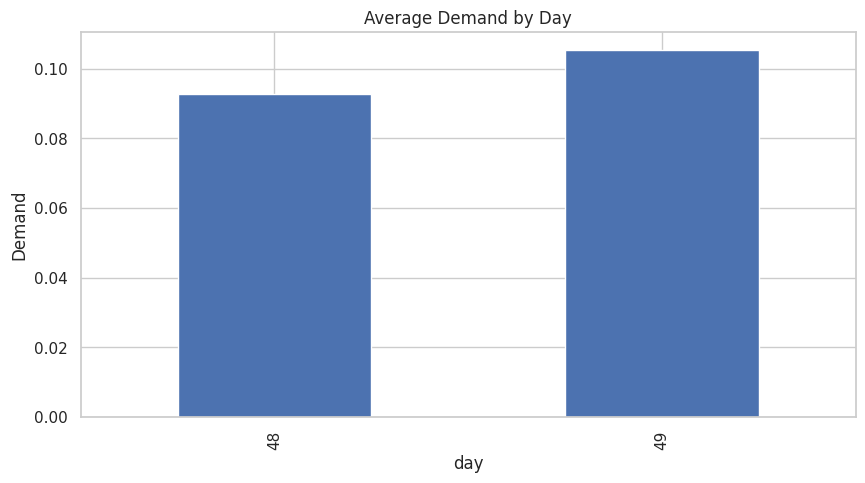

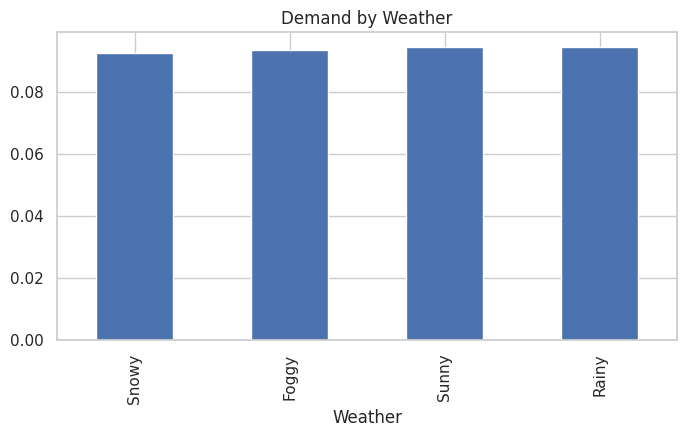

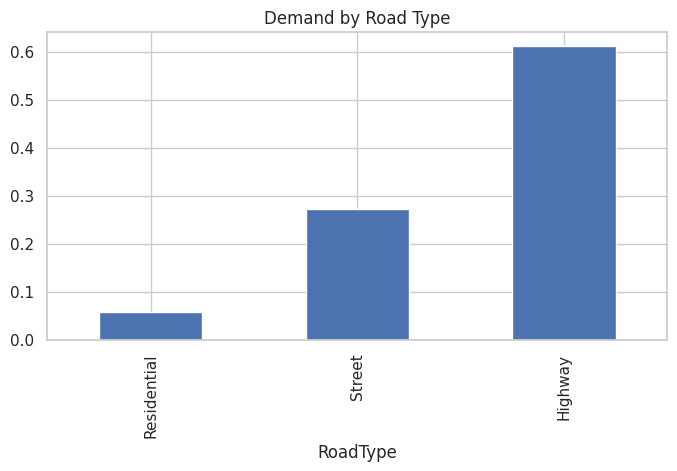

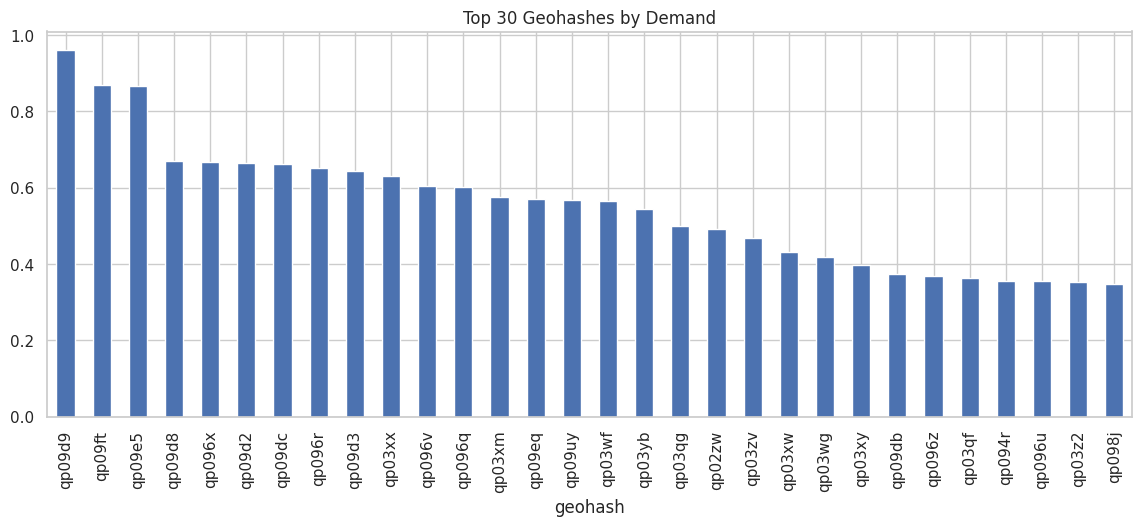

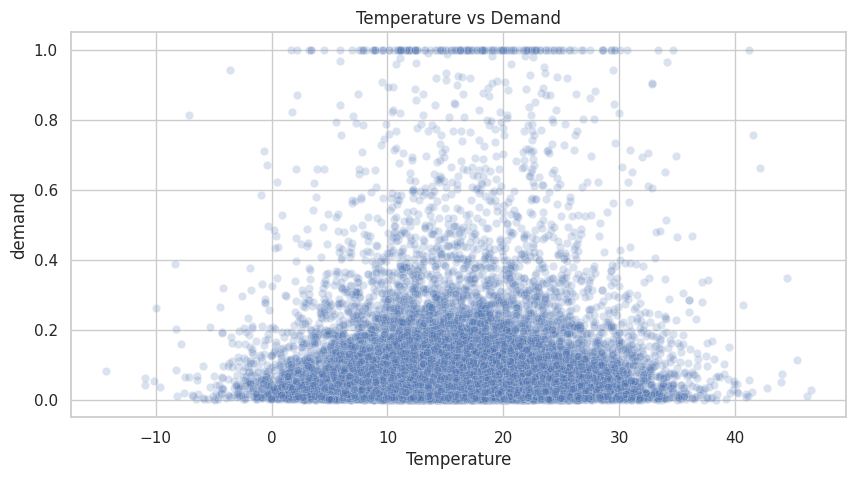

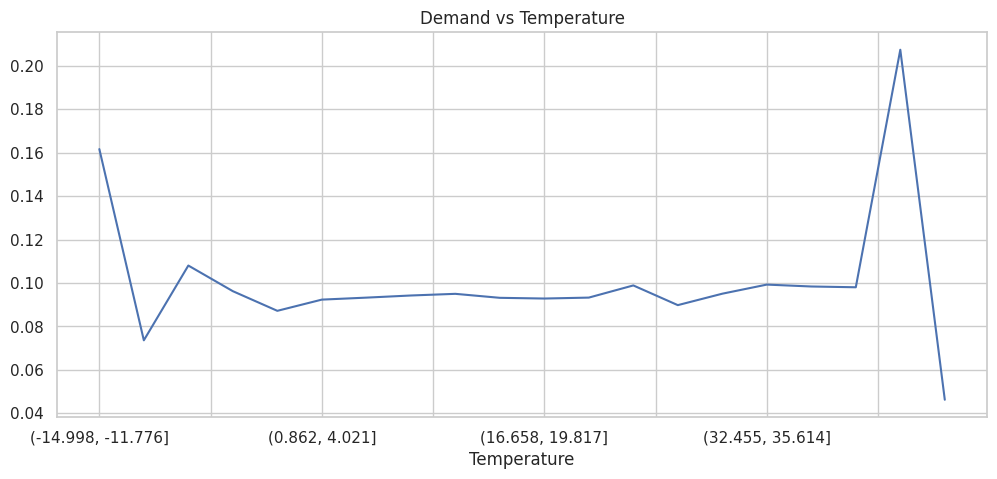

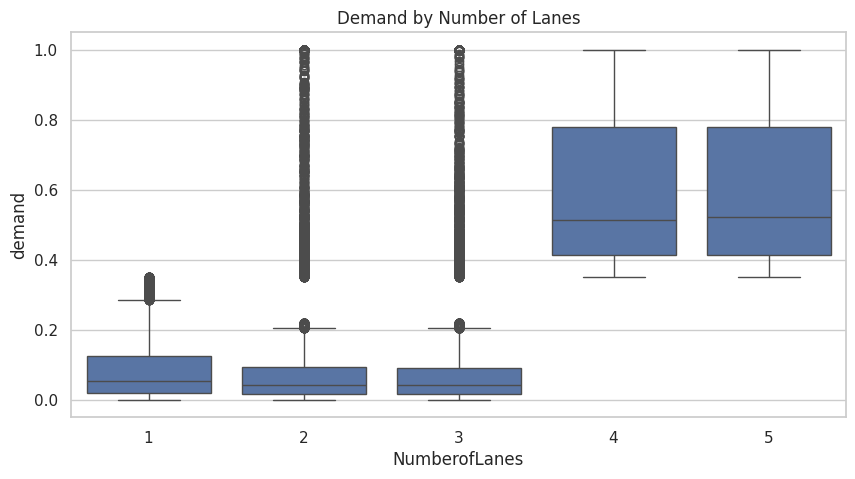

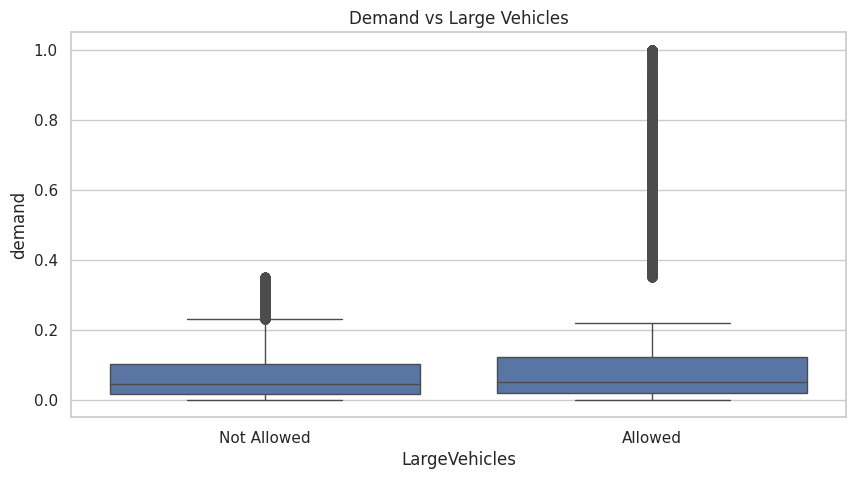

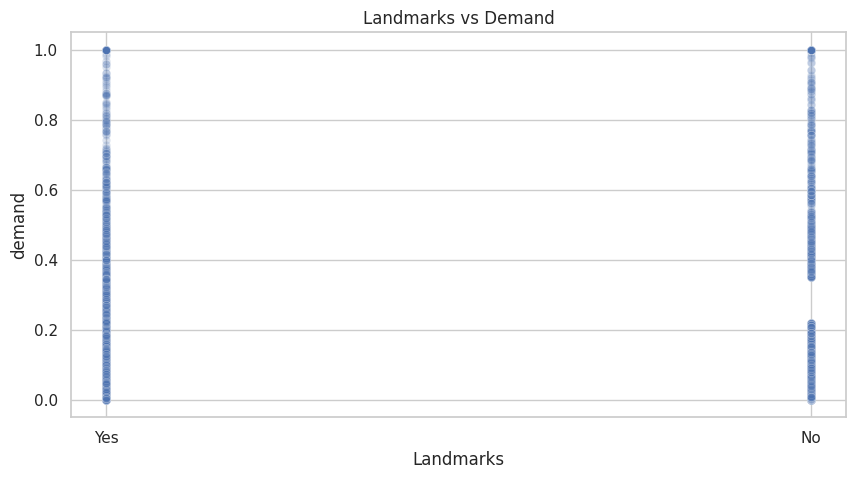

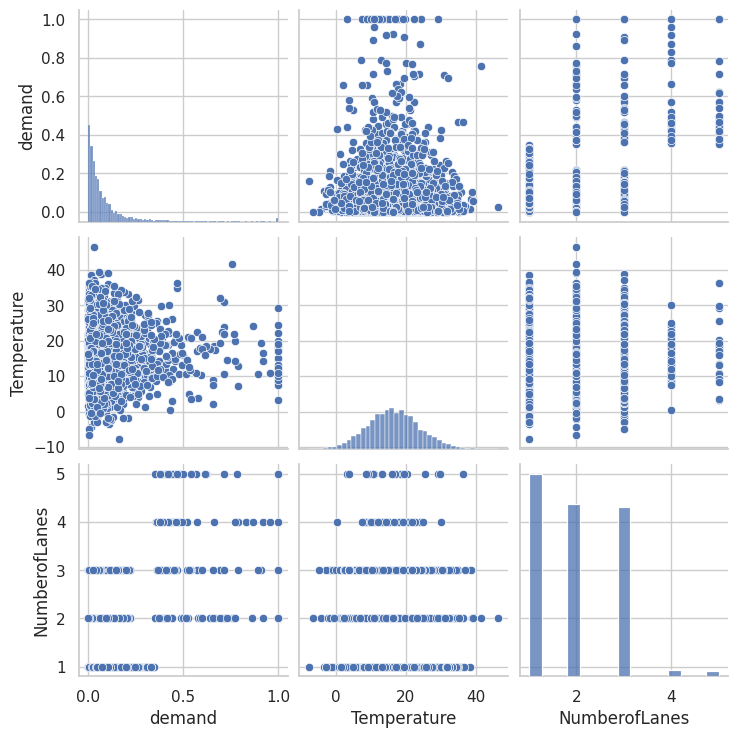


DONE


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(url_train)

sns.set_theme(style="whitegrid")

TARGET = "demand"

print("="*80)
print("DATASET INFO")
print("="*80)
print(df.shape)
print()
print(df[TARGET].describe())

# ==========================================================
# TARGET DISTRIBUTION
# ==========================================================

fig, ax = plt.subplots(1,2, figsize=(15,5))

sns.histplot(df[TARGET], bins=100, kde=True, ax=ax[0])
ax[0].set_title("Demand Distribution")

sns.boxplot(x=df[TARGET], ax=ax[1])
ax[1].set_title("Demand Boxplot")

plt.tight_layout()
plt.show()

# ==========================================================
# NUMERIC CORRELATIONS
# ==========================================================

num_cols = df.select_dtypes(include=np.number).columns

corr = df[num_cols].corr(method="spearman")

plt.figure(figsize=(16,12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)
plt.title("Spearman Correlation Heatmap")
plt.show()

# ==========================================================
# CORRELATION WITH TARGET
# ==========================================================

target_corr = (
    corr[TARGET]
    .sort_values()
)

plt.figure(figsize=(8,10))
target_corr.plot(kind="barh")
plt.title("Correlation With Demand")
plt.show()

# ==========================================================
# DEMAND BY HOUR
# ==========================================================

if "hour" in df.columns:

    plt.figure(figsize=(12,5))

    hourly = (
        df.groupby("hour")[TARGET]
        .mean()
    )

    plt.plot(hourly.index, hourly.values, marker="o")
    plt.title("Average Demand by Hour")
    plt.xlabel("Hour")
    plt.ylabel("Demand")

    plt.show()

# ==========================================================
# DEMAND BY DAY
# ==========================================================

if "day" in df.columns:

    plt.figure(figsize=(10,5))

    daily = (
        df.groupby("day")[TARGET]
        .mean()
    )

    daily.plot(kind="bar")

    plt.title("Average Demand by Day")
    plt.ylabel("Demand")

    plt.show()

# ==========================================================
# HOUR x DAY HEATMAP
# ==========================================================

if ("hour" in df.columns) and ("day" in df.columns):

    pivot = df.pivot_table(
        values=TARGET,
        index="hour",
        columns="day",
        aggfunc="mean"
    )

    plt.figure(figsize=(12,8))

    sns.heatmap(
        pivot,
        cmap="viridis"
    )

    plt.title("Demand Heatmap (Hour × Day)")
    plt.show()

# ==========================================================
# WEATHER EFFECT
# ==========================================================

if "Weather" in df.columns:

    weather = (
        df.groupby("Weather")[TARGET]
        .mean()
        .sort_values()
    )

    plt.figure(figsize=(8,4))
    weather.plot(kind="bar")

    plt.title("Demand by Weather")

    plt.show()

# ==========================================================
# ROAD TYPE EFFECT
# ==========================================================

if "RoadType" in df.columns:

    road = (
        df.groupby("RoadType")[TARGET]
        .mean()
        .sort_values()
    )

    plt.figure(figsize=(8,4))
    road.plot(kind="bar")

    plt.title("Demand by Road Type")

    plt.show()

# ==========================================================
# TOP GEOHASHES
# ==========================================================

if "geohash" in df.columns:

    geo = (
        df.groupby("geohash")[TARGET]
        .mean()
        .sort_values(ascending=False)
        .head(30)
    )

    plt.figure(figsize=(14,5))
    geo.plot(kind="bar")

    plt.title("Top 30 Geohashes by Demand")

    plt.show()

# ==========================================================
# TEMPERATURE
# ==========================================================

if "Temperature" in df.columns:

    sample = df.sample(
        min(len(df), 20000),
        random_state=42
    )

    plt.figure(figsize=(10,5))

    sns.scatterplot(
        data=sample,
        x="Temperature",
        y=TARGET,
        alpha=0.2
    )

    plt.title("Temperature vs Demand")

    plt.show()

    bins = pd.cut(
        df["Temperature"],
        bins=20
    )

    temp_curve = (
        df.groupby(bins)[TARGET]
        .mean()
    )

    plt.figure(figsize=(12,5))

    temp_curve.plot()

    plt.title("Demand vs Temperature")

    plt.show()

# ==========================================================
# NUMBER OF LANES
# ==========================================================

if "NumberofLanes" in df.columns:

    plt.figure(figsize=(10,5))

    sns.boxplot(
        data=df,
        x="NumberofLanes",
        y=TARGET
    )

    plt.title("Demand by Number of Lanes")

    plt.show()

# ==========================================================
# LARGE VEHICLES
# ==========================================================

if "LargeVehicles" in df.columns:

    plt.figure(figsize=(10,5))

    sns.boxplot(
        data=df,
        x="LargeVehicles",
        y=TARGET
    )

    plt.title("Demand vs Large Vehicles")

    plt.show()

# ==========================================================
# LANDMARKS
# ==========================================================

if "Landmarks" in df.columns:

    sample = df.sample(
        min(len(df), 20000),
        random_state=42
    )

    plt.figure(figsize=(10,5))

    sns.scatterplot(
        data=sample,
        x="Landmarks",
        y=TARGET,
        alpha=0.2
    )

    plt.title("Landmarks vs Demand")

    plt.show()

# ==========================================================
# RUSH HOUR FLAGS
# ==========================================================

for col in [
    "is_rush_am",
    "is_rush_pm",
    "is_night",
    "is_biz"
]:

    if col in df.columns:

        plt.figure(figsize=(6,4))

        sns.boxplot(
            data=df,
            x=col,
            y=TARGET
        )

        plt.title(f"Demand vs {col}")

        plt.show()

# ==========================================================
# PAIRPLOT OF IMPORTANT FEATURES
# ==========================================================

candidate_cols = [
    c for c in [
        TARGET,
        "Temperature",
        "hour",
        "time_in_mins",
        "Landmarks",
        "NumberofLanes"
    ]
    if c in df.columns
]

if len(candidate_cols) >= 3:

    sample = df[candidate_cols].sample(
        min(len(df), 3000),
        random_state=42
    )

    sns.pairplot(sample)

    plt.show()

print("\nDONE")

## **DATA-PREPROCESSING AND TIME HEIRARCHY**

In [ ]:
def preprocess(df):
    df = df.copy()
    df[['hour', 'minute']] = df['timestamp'].str.split(':', expand=True).astype(float)
    df['time_in_mins'] = df['hour'] * 60 + df['minute']

    # Cyclical encodings
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

    # Spatial hierarchy
    df['geo5'] = df['geohash'].str[:5]
    df['geo4'] = df['geohash'].str[:4]

    # Time-of-day flags
    df['is_rush_am'] = ((df['hour'] >= 7) & (df['hour'] <= 9)).astype(int)
    df['is_rush_pm'] = ((df['hour'] >= 17) & (df['hour'] <= 19)).astype(int)
    df['is_biz']     = ((df['hour'] >= 9) & (df['hour'] <= 17)).astype(int)
    df['is_night']   = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
    df['day_mod7']   = df['day'] % 7

    # Fill missing
    df['RoadType']    = df['RoadType'].fillna('Unknown')
    df['Weather']     = df['Weather'].fillna('Unknown')
    df['Temperature'] = df['Temperature'].fillna(df['Temperature'].median())
    return df

train = preprocess(train)
test  = preprocess(test)

#### **TARGET TRANSFORMATION TO LOG1P**

In [ ]:
train['demand_log'] = np.log1p(train['demand'])
gm_log = train['demand_log'].mean()

### **LEAK-FREE Robust Target Encoding (Geohash + Hour)**

In [ ]:
print("Applying Leak-Free Spatial-Time Target Encoding...")
target_cols = ['feat_geo_hour', 'feat_geo', 'feat_geo5', 'feat_geo4']
for col in target_cols:
    train[col] = np.nan
    test[col]  = np.nan

kf5 = KFold(n_splits=5, shuffle=True, random_state=42)

for tr_i, val_i in kf5.split(train):
    X_tr, X_val = train.iloc[tr_i], train.iloc[val_i]

    # Calculate means on TRAIN fold using the LOG target
    g_h  = X_tr.groupby(['geohash', 'hour'])['demand_log'].mean().to_dict()
    g_geo = X_tr.groupby('geohash')['demand_log'].mean().to_dict()
    g_geo5 = X_tr.groupby('geo5')['demand_log'].mean().to_dict()
    g_geo4 = X_tr.groupby('geo4')['demand_log'].mean().to_dict()

    # Map to VALIDATION fold
    train.loc[val_i, 'feat_geo_hour'] = pd.Series(list(zip(X_val['geohash'], X_val['hour']))).map(g_h).values
    train.loc[val_i, 'feat_geo'] = X_val['geohash'].map(g_geo).values
    train.loc[val_i, 'feat_geo5'] = X_val['geo5'].map(g_geo5).values
    train.loc[val_i, 'feat_geo4'] = X_val['geo4'].map(g_geo4).values

# Map full means to TEST set
g_h_full  = train.groupby(['geohash', 'hour'])['demand_log'].mean().to_dict()
g_geo_full = train.groupby('geohash')['demand_log'].mean().to_dict()
g_geo5_full = train.groupby('geo5')['demand_log'].mean().to_dict()
g_geo4_full = train.groupby('geo4')['demand_log'].mean().to_dict()

test['feat_geo_hour'] = pd.Series(list(zip(test['geohash'], test['hour']))).map(g_h_full).values
test['feat_geo'] = test['geohash'].map(g_geo_full).values
test['feat_geo5'] = test['geo5'].map(g_geo5_full).values
test['feat_geo4'] = test['geo4'].map(g_geo4_full).values

# Fallback Logic
for df in [train, test]:
    df['best_est'] = df['feat_geo_hour']
    df['best_est'] = df['best_est'].fillna(df['feat_geo'])
    df['best_est'] = df['best_est'].fillna(df['feat_geo5'])
    df['best_est'] = df['best_est'].fillna(df['feat_geo4'])
    df['best_est'] = df['best_est'].fillna(gm_log)

    for col in target_cols:
        df[col] = df[col].fillna(df['best_est'])

Applying Leak-Free Spatial-Time Target Encoding...


### **Prepare Categorical Features**

In [ ]:
cat_cols = ['geohash', 'geo5', 'geo4', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']
df_all = pd.concat([train, test]).reset_index(drop=True)

# Factorize to integers for unified model processing
for c in cat_cols:
    df_all[c] = pd.factorize(df_all[c])[0]

train_e = df_all.iloc[:len(train)].copy()
test_e  = df_all.iloc[len(train):].copy()

excl  = ['Index', 'demand', 'demand_log', 'timestamp', 'best_est']

# R² Score: 0.91358816
# best R2 score was achieved on dropping these combination of features.
drop_cols = [
    'feat_geo4',
    'geo4',
    'day_mod7'
]

feats = [
    c for c in train_e.columns
    if c not in excl + drop_cols
]

X = train_e[feats]
# We train on the LOG target
y_log = train_e['demand_log'].values
# We keep raw target just to calculate the final R2 score for our print statements
y_raw = train_e['demand'].values
Xt = test_e[feats]

print(f"Training on {feats} features...")

Training on ['geohash', 'day', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'hour', 'minute', 'time_in_mins', 'hour_sin', 'hour_cos', 'geo5', 'is_rush_am', 'is_rush_pm', 'is_biz', 'is_night', 'feat_geo_hour', 'feat_geo', 'feat_geo5'] features...


### RESULTS OF VARIOUS COMBINATIONS TRIED -

| Exp #          | Dropped Columns                                                                   |       R² Score |
| -------------- | --------------------------------------------------------------------------------- | -------------: |
| 0 (Baseline)   | None                                                                              |        ~0.9120 |
| 1              | `time_in_mins`                                                                    |         0.9118 |
| 2              | `feat_geo4`, `geo4`, `day_mod7`                                                   | **0.91358816** |
| 3 (Best Param Run) | `feat_geo4`, `geo4`, `day_mod7`                                                   | **0.91360430** |
| 4              | `feat_geo4`, `geo4`, `day_mod7`, `is_rush_am`, `is_rush_pm`, `is_biz`, `is_night` |     0.91236342 |
| 5              | `feat_geo4`, `geo4`, `day_mod7`, `geo5`, `feat_geo5`                              |     0.90729370 |


# **CORRELATION ANALYSIS ON FINAL FEATURES**

### CORRELATION HEATMAP:

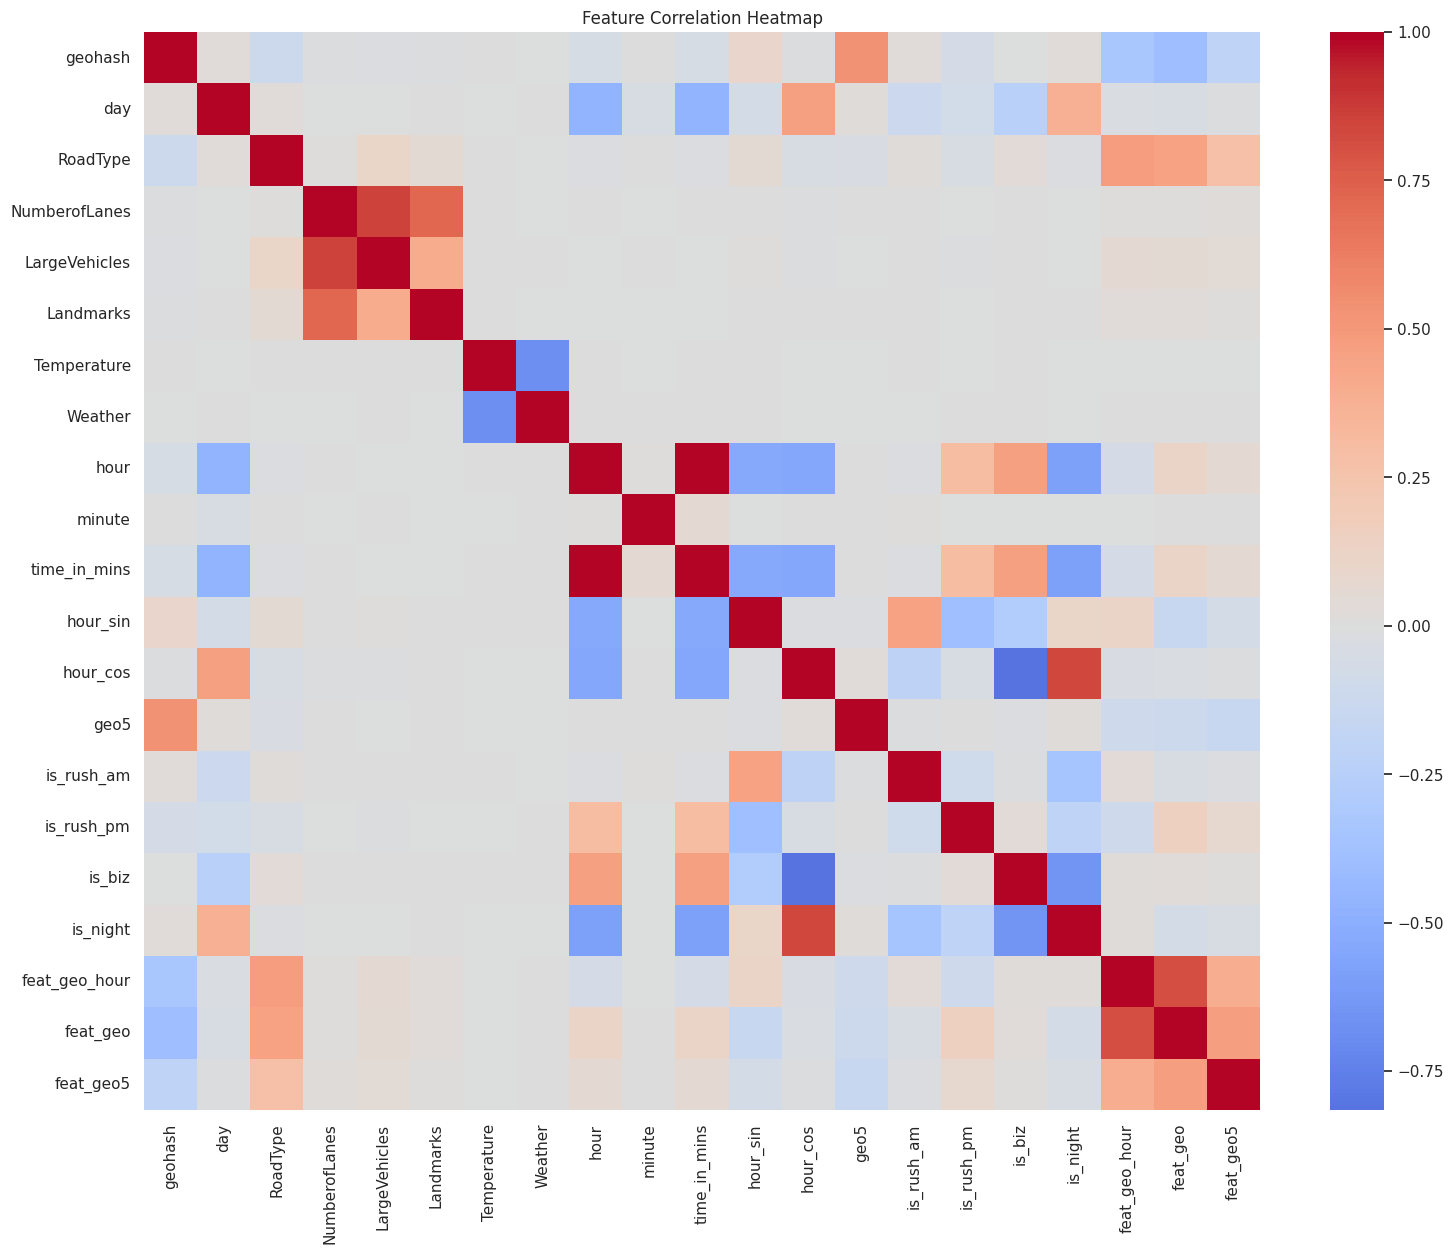

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_features = [
    c for c in train_e.columns
    if c not in excl + drop_cols
]

corr_matrix = train_e[corr_features].corr(method='spearman')

plt.figure(figsize=(18,14))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    square=False
)

plt.title("Feature Correlation Heatmap")
plt.show()

### CORRELATION PAIRS:

In [ ]:
corr_pairs = (
    corr_matrix.abs()
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs = corr_pairs[
    corr_pairs < 1.0
]

print(corr_pairs.head(50))

time_in_mins   hour             0.998704
hour           time_in_mins     0.998704
LargeVehicles  NumberofLanes    0.856843
NumberofLanes  LargeVehicles    0.856843
is_night       hour_cos         0.837278
hour_cos       is_night         0.837278
               is_biz           0.815520
is_biz         hour_cos         0.815520
feat_geo_hour  feat_geo         0.812218
feat_geo       feat_geo_hour    0.812218
Landmarks      NumberofLanes    0.718327
NumberofLanes  Landmarks        0.718327
Weather        Temperature      0.683355
Temperature    Weather          0.683355
is_night       is_biz           0.648095
is_biz         is_night         0.648095
hour           is_night         0.584160
is_night       hour             0.584160
               time_in_mins     0.583403
time_in_mins   is_night         0.583403
hour           hour_cos         0.553027
hour_cos       hour             0.553027
               time_in_mins     0.552310
time_in_mins   hour_cos         0.552310
hour_sin       h

# **TRAINING ENSEMBLE (LightGBM + CATBOOST)**

In [ ]:
# lgb_params were tuned using Optuna Tuner.
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.028924540300712398,
    'num_leaves': 1844,
    'feature_fraction': 0.8205344746646264,
    'bagging_fraction': 0.9769533888153578,
    'lambda_l1': 0.000238261269429757,
    'lambda_l2': 4.632381262283322,
    'bagging_freq': 9,
    'random_state': 42,
    'n_estimators': 4611,
    'max_depth': -1,
    'verbose': -1,
    'min_child_samples': 4

}

cb_params = {
    'iterations': 2000,
    'learning_rate': 0.04,
    'depth': 8,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'verbose': False,
    # CatBoost explicitly handles categorical columns mathematically
    'cat_features': [feats.index(c) for c in cat_cols if c in feats]
}

val_preds_lgb = np.zeros(len(train_e))
test_preds_lgb = np.zeros(len(test_e))
val_preds_cb = np.zeros(len(train_e))
test_preds_cb = np.zeros(len(test_e))

for fold, (tr_i, val_i) in enumerate(kf5.split(X, y_log)):
    print(f"--- Training Fold {fold+1}/5 ---")
    X_tr, y_tr = X.iloc[tr_i], y_log[tr_i]
    X_va, y_va = X.iloc[val_i], y_log[val_i]

    # 1. Train LightGBM
    model_lgb = lgb.LGBMRegressor(**lgb_params)
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(100, verbose=False)])
    val_preds_lgb[val_i] = model_lgb.predict(X_va)
    test_preds_lgb      += model_lgb.predict(Xt) / 5

    # 2. Train CatBoost
    model_cb = CatBoostRegressor(**cb_params)
    model_cb.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=100)
    val_preds_cb[val_i] = model_cb.predict(X_va)
    test_preds_cb      += model_cb.predict(Xt) / 5

### FEATURE IMPORTANCE AFTER MODEL TRAINING

In [ ]:
from lightgbm import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plot_importance(model_lgb, max_num_features=30)
plt.show()

# **OPTUNA PARAMETER TUNING**

In [ ]:
import optuna
import lightgbm as lgb

from sklearn.metrics import r2_score
from sklearn.model_selection import KFold

# Fixed CatBoost prediction
cb_pred = model_cb.predict(X_va)

def objective(trial):

    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.08,
            log=True
        ),

        'num_leaves': trial.suggest_int(
            'num_leaves',
            127,
            4095,
            log=True
        ),

        'max_depth': trial.suggest_int(
            'max_depth',
            -1,
            16
        ),

        'min_child_samples': trial.suggest_int(
            'min_child_samples',
            2,
            50
        ),

        'feature_fraction': trial.suggest_float(
            'feature_fraction',
            0.6,
            1.0
        ),

        'bagging_fraction': trial.suggest_float(
            'bagging_fraction',
            0.6,
            1.0
        ),

        'bagging_freq': trial.suggest_int(
            'bagging_freq',
            1,
            10
        ),

        'lambda_l1': trial.suggest_float(
            'lambda_l1',
            1e-4,
            10,
            log=True
        ),

        'lambda_l2': trial.suggest_float(
            'lambda_l2',
            1e-4,
            10,
            log=True
        ),

        'n_estimators': trial.suggest_int(
            'n_estimators',
            1000,
            5000
        ),

        'random_state': 42
    }

    model = lgb.LGBMRegressor(**params)

    model.fit(
        X_tr,
        y_tr
    )

    lgb_pred = model.predict(X_va)

    # optimize ensemble weight too
    weight = trial.suggest_float(
        'lgb_weight',
        0.0,
        1.0
    )

    pred = (
        weight * lgb_pred
        + (1 - weight) * cb_pred
    )

    score = r2_score(y_va, pred)

    return score

study = optuna.create_study(
    direction='maximize',
    study_name='lgb_ensemble'
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True
)

print("\nBEST SCORE")
print(study.best_value)

print("\nBEST PARAMS")
print(study.best_params)

# **Ensemble and Reverse Transformation**

In [ ]:
# Reverse the log1p transform using expm1!
val_preds_lgb_raw = np.expm1(val_preds_lgb)
val_preds_cb_raw  = np.expm1(val_preds_cb)
test_preds_lgb_raw = np.expm1(test_preds_lgb)
test_preds_cb_raw  = np.expm1(test_preds_cb)

# BLEND RATIO AS PER OPTUNA RESULTS
val_preds_ens = (val_preds_lgb_raw * 0.4182067444554326) + (val_preds_cb_raw * (1-0.4182067444554326))
test_preds_ens = (test_preds_lgb_raw * 0.4182067444554326) + (test_preds_cb_raw * (1-0.4182067444554326))

print("\n--- Model Performance ---")
print(f"LightGBM OOF R2 Score: {max(0, 100 * r2_score(y_raw, val_preds_lgb_raw)):.2f}")
print(f"CatBoost OOF R2 Score: {max(0, 100 * r2_score(y_raw, val_preds_cb_raw)):.2f}")
print(f"ENSEMBLE OOF R2 Score: {max(0, 100 * r2_score(y_raw, val_preds_ens)):.2f}")

# **SAVING SUBMISSION FILE**

In [ ]:
test_orig  = pd.read_csv(url_test)
submission = pd.DataFrame({
    'Index':  test_orig['Index'],
    'demand': np.clip(test_preds_ens, 0, 1) # Ensure bounded predictions
})

submission.to_csv('submission.csv', index=False)
print(f"\nSaved submission.csv!")

# ADDING ADDITIONAL BIAS TO IMPROVE ACCURACY
The model severly underperforms on training data where it has to predict values greater than 0.8. To fix this, additional bias is added to the model which was seen to improve the overall R2 score.

In [ ]:
sub = pd.read_csv("submission.csv")
pred_adj = sub["demand"].copy()

pred_adj[pred_adj > 0.8] += 0.06
pred_adj[pred_adj > 0.2] -= 0.013

pred_adj = np.clip(pred_adj, 0, 1)

# adding a post processing correction of 0.03 improved the model upto 91.49

sub["demand"] = pred_adj
sub.to_csv("submission.csv", index=False)